In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [25]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)

In [15]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)


In [16]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 1024)
        self.fc2 = PrunableLinear(1024, 512)
        self.fc3 = PrunableLinear(512, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.3)

        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=0.3)

        x = self.fc3(x)
        return x

In [17]:
def sparsity_loss(model):
    loss = 0
    count = 0

    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores)
            loss += torch.mean(gates)
            count += 1

    return loss / count

In [18]:
def train(model, loader, lambda_val=0.01, epochs=20):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            ce_loss = F.cross_entropy(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = ce_loss + lambda_val * sp_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()

        avg_loss = total_loss / len(loader)
        loss_history.append(avg_loss)

        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

    return loss_history

In [19]:
def test(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    acc = 100 * correct / total
    print(f"Accuracy: {acc:.2f}%")
    return acc

In [20]:
def calculate_sparsity(model, threshold=0.05):
    total = 0
    pruned = 0

    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores)
            total += gates.numel()
            pruned += torch.sum(gates < threshold).item()

    sparsity = (pruned / total) * 100
    print(f"Sparsity: {sparsity:.2f}%")
    return sparsity

In [21]:
def plot_loss(loss_history):
    plt.plot(loss_history)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

def plot_gate_distribution(model):
    gates_all = []

    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores).detach().cpu().numpy().flatten()
            gates_all.extend(gates)

    plt.hist(gates_all, bins=50)
    plt.axvline(0.05)
    plt.title("Gate Distribution")
    plt.show()

Epoch 1 | Loss: 1.7344
Epoch 2 | Loss: 1.5226
Epoch 3 | Loss: 1.4264
Epoch 4 | Loss: 1.3566
Epoch 5 | Loss: 1.2955
Epoch 6 | Loss: 1.2418
Epoch 7 | Loss: 1.1962
Epoch 8 | Loss: 1.1486
Epoch 9 | Loss: 1.1083
Epoch 10 | Loss: 1.0710
Epoch 11 | Loss: 0.9528
Epoch 12 | Loss: 0.9011
Epoch 13 | Loss: 0.8699
Epoch 14 | Loss: 0.8448
Epoch 15 | Loss: 0.8151
Epoch 16 | Loss: 0.7926
Epoch 17 | Loss: 0.7658
Epoch 18 | Loss: 0.7431
Epoch 19 | Loss: 0.7241
Epoch 20 | Loss: 0.7008
Accuracy: 54.33%
Sparsity: 0.25%


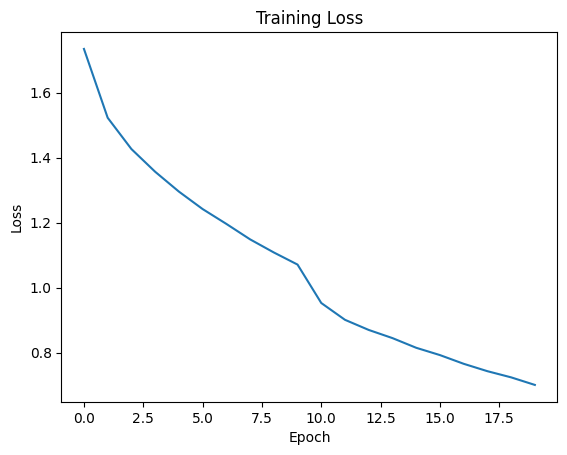

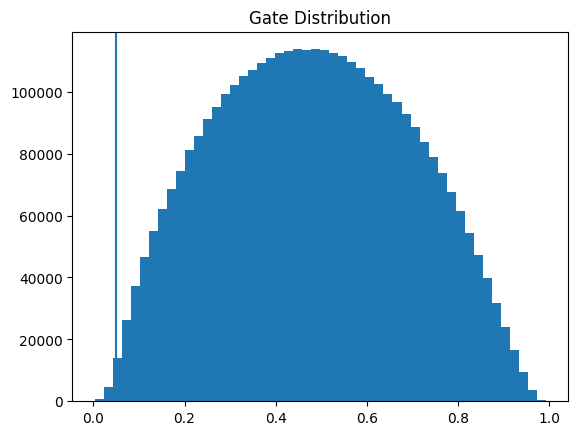

In [22]:
model = PrunableNet()

loss_history = train(model, train_loader, lambda_val=0.05, epochs=20)

acc = test(model, test_loader)

sparsity = calculate_sparsity(model)

plot_loss(loss_history)

plot_gate_distribution(model)